In [23]:
import pandas as pd
import re
import string
import nltk

In [24]:
df = pd.read_csv(r"C:\Users\Pavithra\Desktop\final project\data\output.csv")

In [25]:
df.head()

,News ID,Category,Topic,Headline,News body,Title entity,Entity content
0,N10000,sports,soccer,Predicting Atlanta United's lineup against Col...,"Only FIVE internationals allowed, count em, FI...","{""Atlanta United's"": 'Atlanta United FC'}","{'Atlanta United FC': {'type': 'item', 'id': '..."
1,N10001,news,newspolitics,Mitch McConnell: DC statehood push is 'full bo...,WASHINGTON -- Senate Majority Leader Mitch McC...,"{'DC': 'Washington, D.C.'}","{'Washington, D.C.': {'type': 'item', 'id': 'Q..."
2,N10002,news,newsus,Home In North Highlands Damaged By Fire,NORTH HIGHLANDS (CBS13) Fire damaged a home ...,{},{}
3,N10003,news,newspolitics,Meghan McCain blames 'liberal media' and 'thir...,Meghan McCain is speaking out after a journali...,{},{}
4,N10004,news,newsworld,Today in History: Aug 1,"1714: George I becomes King Georg Ludwig, Elec...",{},{}


In [26]:
df.shape

(113762, 7)

In [27]:
df.isnull().sum()

News ID            0
Category           0
Topic              0
Headline           0
News body         58
Title entity       0
Entity content     0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113762 entries, 0 to 113761
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   News ID         113762 non-null  object
 1   Category        113762 non-null  object
 2   Topic           113762 non-null  object
 3   Headline        113762 non-null  object
 4   News body       113704 non-null  object
 5   Title entity    113762 non-null  object
 6   Entity content  113762 non-null  object
dtypes: object(7)
memory usage: 6.1+ MB


In [30]:
df['Category'].value_counts()

Category
sports           30557
news             26689
finance          10571
lifestyle         7405
autos             5494
travel            5381
foodanddrink      5286
video             4968
tv                3981
health            3799
weather           3298
music             2547
movies            1996
entertainment     1487
kids               299
europe               2
northamerica         1
adexperience         1
Name: count, dtype: int64

In [ ]:
# Data Cleaning and Preprocessing including Stopword Removal

from nltk.tokenize import word_tokenize


def clean_text_classification(text):

    # This part handles cases where the input is not a string
    if not isinstance(text,str): 
        return ""
    
    # Remove HTML tags
    text =  re.sub(r"<.*?>"," ",text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+"," ",text)

    # Remove emojis
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    #  Remove special symbols except letters, numbers, .,!?, and spaces
    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", " ", text)

    #  Convert to lowercase
    text = text.lower()

    # Normalize whitespace
    text = " ".join(text.split())

    # Tokenization
    tokens = word_tokenize(text)

    # Remove punctuation and tokens, Keeps only meaningful words
    tokens = [word for word in tokens if word.isalnum()]
    
    text = " ".join(tokens)

    return text

In [32]:
df["text"] = (df["Headline"] + " " + df["News body"].fillna(""))
df["clean_text_cls"] = df["text"].apply(clean_text_classification)

In [33]:
df.head()

,News ID,Category,Topic,Headline,News body,Title entity,Entity content,text,clean_text_cls
0,N10000,sports,soccer,Predicting Atlanta United's lineup against Col...,"Only FIVE internationals allowed, count em, FI...","{""Atlanta United's"": 'Atlanta United FC'}","{'Atlanta United FC': {'type': 'item', 'id': '...",Predicting Atlanta United's lineup against Col...,predicting atlanta united s lineup against col...
1,N10001,news,newspolitics,Mitch McConnell: DC statehood push is 'full bo...,WASHINGTON -- Senate Majority Leader Mitch McC...,"{'DC': 'Washington, D.C.'}","{'Washington, D.C.': {'type': 'item', 'id': 'Q...",Mitch McConnell: DC statehood push is 'full bo...,mitch mcconnell dc statehood push is full bore...
2,N10002,news,newsus,Home In North Highlands Damaged By Fire,NORTH HIGHLANDS (CBS13) Fire damaged a home ...,{},{},Home In North Highlands Damaged By Fire NORTH ...,home in north highlands damaged by fire north ...
3,N10003,news,newspolitics,Meghan McCain blames 'liberal media' and 'thir...,Meghan McCain is speaking out after a journali...,{},{},Meghan McCain blames 'liberal media' and 'thir...,meghan mccain blames liberal media and third w...
4,N10004,news,newsworld,Today in History: Aug 1,"1714: George I becomes King Georg Ludwig, Elec...",{},{},Today in History: Aug 1 1714: George I becomes...,today in history aug 1 1714 george i becomes k...


In [34]:
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
df["label"] = le.fit_transform(df["Category"])

# Save for inference (important for Streamlit)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

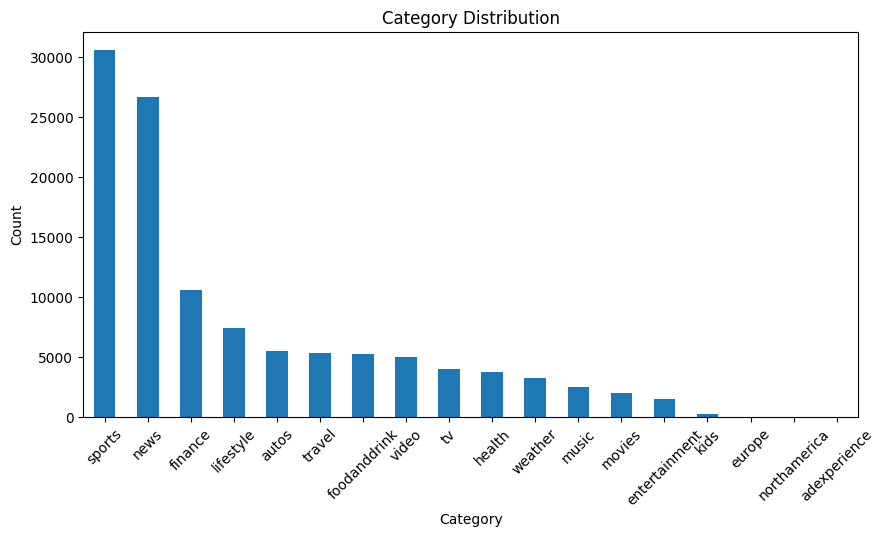

In [35]:
# 1.1 Category Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

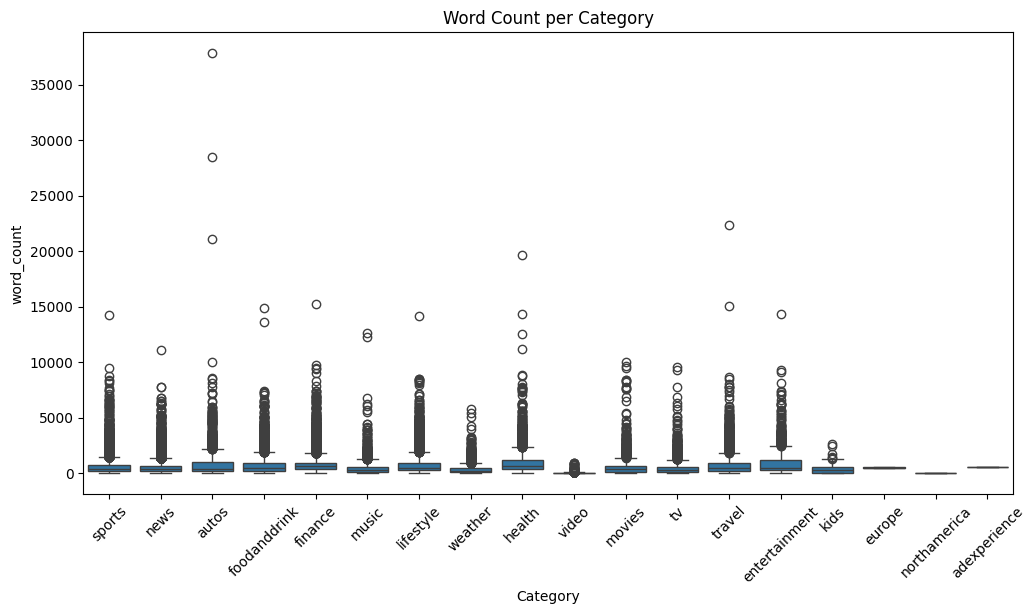

In [36]:
import seaborn as sns
def word_count(text):
    return len(str(text).split())

df["word_count"] = df["clean_text_cls"].apply(word_count)

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Category", y="word_count")
plt.xticks(rotation=45)
plt.title("Word Count per Category")
plt.show()

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import joblib

In [38]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text_cls"],
    df["label"],
    test_size=0.2,
    random_state=42
)

✅ 🎯 Best 2 Models for Your Project
🥇 1. Linear SVM + TF-IDF
🥈 2. Logistic Regression + TF-IDF
🔹 Why These Two?
🥇 1. Linear SVM (Best Performer)
✅ Why we use it:
Works extremely well for high-dimensional sparse data (text)
Handles large vocabularies efficiently
Maximizes margin → better generalization
Usually gives highest accuracy / F1 in text classification
🧠 In simple words:

“SVM finds the best boundary that separates categories with maximum margin.”

🥈 2. Logistic Regression (Baseline + Probabilities)
✅ Why we use it:
Simple, fast, and interpretable
Works very well with TF-IDF
Provides probability scores (important for UI / confidence display)
Strong baseline for comparison
🧠 In simple words:

“It predicts the probability of a text belonging to each category.”

In [39]:
# Four Models 

pipelines = {
    "LR_TFIDF": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=2, max_df=0.9, stop_words="english")),
        ("clf", LogisticRegression(max_iter=8000, class_weight="balanced"))
    ]),

    "LR_BOW": Pipeline([
        ("bow", CountVectorizer(max_features=8000, ngram_range=(1,2), min_df=2, max_df=0.9, stop_words="english")),
        ("clf", LogisticRegression(max_iter=8000, class_weight="balanced"))
    ]),

    "SVM_TFIDF": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=2, max_df=0.9, stop_words="english")),
        ("clf", LinearSVC(class_weight="balanced"))
    ]),

    "SVM_BOW": Pipeline([
        ("bow", CountVectorizer(max_features=8000, ngram_range=(1,2), min_df=2, max_df=0.9, stop_words="english")),
        ("clf", LinearSVC(class_weight="balanced"))
    ]),
}

In [40]:
# Evaluate Models
def evaluate_model(name, pipeline):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds, average="weighted", zero_division=0))
    print("Recall:", recall_score(y_test, preds, average="weighted", zero_division=0))
    print("F1 Score:", f1_score(y_test, preds, average="weighted", zero_division=0))
    print("\nClassification Report:\n", classification_report(y_test, preds, zero_division=0))

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Weighted F1": f1_score(y_test, preds, average="weighted")
    }

In [41]:
# Four Models Run


all_results = []

for name, model in pipelines.items():
    result = evaluate_model(name, model)
    all_results.append(result)

results_df = pd.DataFrame(all_results)
print("\n====== FINAL COMPARISON OF 4 MODELS ======")
print(results_df)


===== LR_TFIDF =====
Accuracy: 0.7568232760515097
Precision: 0.7957058204690365
Recall: 0.7568232760515097
F1 Score: 0.7646413981825521

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.76      0.88      0.82      1074
           2       0.44      0.53      0.48       299
           4       0.82      0.80      0.81      2122
           5       0.80      0.86      0.83      1130
           6       0.73      0.84      0.78       741
           7       0.10      0.30      0.15        66
           8       0.64      0.65      0.64      1408
           9       0.61      0.78      0.69       375
          10       0.61      0.76      0.68       491
          11       0.87      0.57      0.69      5395
          12       0.00      0.00      0.00         0
          13       0.98      0.91      0.94      6185
          14       0.55      0.71      0.62      1082
          15       0.58    

c:\Users\Pavithra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



===== SVM_BOW =====
Accuracy: 0.7314639827715027
Precision: 0.7504948893029607
Recall: 0.7314639827715027
F1 Score: 0.7373980794286003

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.78      0.80      0.79      1074
           2       0.42      0.39      0.40       299
           3       0.00      0.00      0.00         0
           4       0.79      0.75      0.77      2122
           5       0.72      0.77      0.74      1130
           6       0.71      0.74      0.73       741
           7       0.09      0.12      0.10        66
           8       0.58      0.57      0.57      1408
           9       0.58      0.65      0.61       375
          10       0.53      0.65      0.58       491
          11       0.78      0.63      0.70      5395
          12       0.00      0.00      0.00         0
          13       0.95      0.93      0.94      6185
          14       0.52     

In [42]:
best_model_name = results_df.sort_values("Weighted F1", ascending=False).iloc[0]["Model"]
print("\nBest Model:", best_model_name)


Best Model: SVM_TFIDF


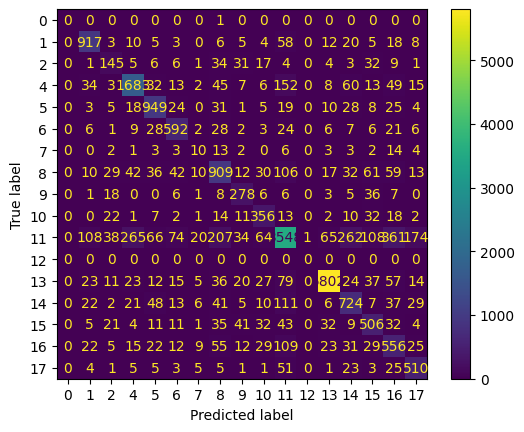

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(pipelines[best_model_name], X_test, y_test)
plt.show()

In [44]:
best_model = pipelines[best_model_name]
best_model.fit(X_train, y_train)

joblib.dump(best_model, "best_text_ML_model.pkl")
print("Model saved as best_text_ML_model.pkl")

Model saved as best_text_ML_model.pkl


**DEEP LEARNING MODELS**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Input,
    Conv1D,
    GlobalMaxPooling1D,
    Concatenate,
    SpatialDropout1D,     
    BatchNormalization      
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau 

from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

In [47]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text_cls"],
    df["label"],
    test_size=0.2,
    random_state=42
)

In [48]:
num_classes = len(df["label"].unique())

In [ ]:
# Tokenizer
MAX_WORDS = 50000
MAX_LEN = 150
EMBED_DIM = 300   # MUST MATCH Word2Vec or GloVe EMBEDDING DIMENSION

tokenizer = Tokenizer(num_words=MAX_WORDS,oov_token="<OOV>")
tokenizer.fit_on_texts(X_train) # this assigns index to all words in the corpus means this have word and their index

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train) # converts each text to a sequence of integers based on the tokenizer's word index
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences to ensure uniform input size
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post")

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1) # +1 for padding token which is index 0

In [51]:
from gensim.downloader import load
w2v_model = load("word2vec-google-news-300")

In [52]:
# Vector Embeddings of word2vec

import numpy as np

embedding_matrix = np.zeros((vocab_size,EMBED_DIM))

for word,i in tokenizer.word_index.items():
    if i<MAX_WORDS:
        if word in w2v_model:
            embedding_matrix[i] = w2v_model[word]
        else:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

In [53]:
from gensim.downloader import load

# This will download once and cache locally
glove_model = load("glove-wiki-gigaword-300")

print("GloVe model loaded!")
print(glove_model["india"][:10])

GloVe model loaded!
[-0.11337   -0.57114    0.070453  -0.36241   -0.050125  -0.73224
  0.0053144  0.73643   -0.47838   -2.0426   ]


In [54]:
# Vector Embeddings of GloVe
embedding_matrix_glove = np.zeros((vocab_size,EMBED_DIM))
for word,i in tokenizer.word_index.items():
    if i<MAX_WORDS:
        if word in glove_model:
            embedding_matrix_glove[i] = glove_model[word]
        else:
            embedding_matrix_glove[i] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

embedding_matrix_glove.shape

(50000, 300)

In [55]:
# Common Callbacks for All DL Models

# NEW: ReduceLROnPlateau -> lower LR when val_loss plateaus (stabilizes training)
lr_reducer = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    verbose=1,
    min_lr=1e-6
)

early = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))


####  MODEL 1: BiLSTM + Word2Vec

In [ ]:
bilstm_w2v = Sequential([
    Embedding(
        vocab_size,
        EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(128, return_sequences=False, dropout=0.3)),
    BatchNormalization(),
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

bilstm_w2v.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

print("\n=== Training BiLSTM + Word2Vec ===")
history1 = bilstm_w2v.fit(
    X_train_pad, y_train,
    epochs=6,                    
    batch_size=128,              
    validation_data=(X_test_pad, y_test),
    callbacks=[early, lr_reducer],  
    verbose=1, class_weight=class_weights
)


c:\Users\Pavithra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



=== Training BiLSTM + Word2Vec ===
Epoch 1/6
712/712 ━━━━━━━━━━━━━━━━━━━━ 522s 728ms/step - accuracy: 0.2318 - loss: 220.6830 - val_accuracy: 0.2396 - val_loss: 7.4249 - learning_rate: 0.0010
Epoch 2/6
712/712 ━━━━━━━━━━━━━━━━━━━━ 306s 430ms/step - accuracy: 0.2376 - loss: 131.0169 - val_accuracy: 0.2538 - val_loss: 6.5390 - learning_rate: 0.0010
Epoch 3/6
712/712 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.2405 - loss: 119.3544
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
712/712 ━━━━━━━━━━━━━━━━━━━━ 397s 558ms/step - accuracy: 0.2427 - loss: 116.3559 - val_accuracy: 0.2542 - val_loss: 6.7258 - learning_rate: 0.0010
Epoch 4/6
712/712 ━━━━━━━━━━━━━━━━━━━━ 382s 537ms/step - accuracy: 0.2476 - loss: 106.3521 - val_accuracy: 0.2583 - val_loss: 6.2421 - learning_rate: 5.0000e-04
Epoch 5/6
712/712 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.2523 - loss: 97.7841
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
712/712 ━━━━━

####  MODEL 2: TextCNN + Word2Vec

In [ ]:
input_layer = Input(shape=(MAX_LEN,))
embed_layer = Embedding(
    vocab_size,
    EMBED_DIM,
    input_length=MAX_LEN,
    weights=[embedding_matrix],
    trainable=False         
)(input_layer)

# NEW: SpatialDropout1D here also helps CNN generalization
x = SpatialDropout1D(0.2)(embed_layer)

conv3 = Conv1D(128, 3, activation="relu")(x)
conv4 = Conv1D(128, 4, activation="relu")(x)
conv5 = Conv1D(128, 5, activation="relu")(x)

pool3 = GlobalMaxPooling1D()(conv3)
pool4 = GlobalMaxPooling1D()(conv4)
pool5 = GlobalMaxPooling1D()(conv5)

merged = Concatenate()([pool3, pool4, pool5])

# BatchNormalization before dense
merged = BatchNormalization()(merged)

dense = Dense(256, activation="relu")(merged)
dropout = Dropout(0.5)(dense)  
output_layer = Dense(num_classes, activation="softmax")(dropout)

textcnn_w2v = Model(inputs=input_layer, outputs=output_layer)

textcnn_w2v.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

print("\n=== Training TextCNN + Word2Vec ===")
history2 = textcnn_w2v.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=8,                  
    batch_size=256,           
    callbacks=[early, lr_reducer],
    verbose=1, class_weight=class_weights
)


=== Training TextCNN + Word2Vec ===
Epoch 1/8
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.2146 - loss: 728.6833
Epoch 1: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
285/285 ━━━━━━━━━━━━━━━━━━━━ 169s 584ms/step - accuracy: 0.2305 - loss: 329.1786 - val_accuracy: 0.2308 - val_loss: 9.5701 - learning_rate: 0.0010
Epoch 2/8
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.2350 - loss: 145.4263
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
285/285 ━━━━━━━━━━━━━━━━━━━━ 168s 591ms/step - accuracy: 0.2364 - loss: 140.9029 - val_accuracy: 0.2313 - val_loss: 8.1692 - learning_rate: 5.0000e-04
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


#### MODEL 3: BiLSTM + GloVe

In [ ]:
bilstm_glove = Sequential([
    Embedding(
        vocab_size,
        EMBED_DIM,
        weights=[embedding_matrix_glove],
        input_length=MAX_LEN,
        trainable=False
    ),
    SpatialDropout1D(0.2),       
    Bidirectional(
        LSTM(128, return_sequences=False, dropout=0.3)  
    ),
    BatchNormalization(),         
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

bilstm_glove.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

print("\n=== Training BiLSTM + GloVe ===")
history3 = bilstm_glove.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=8,           
    batch_size=128,
    callbacks=[early, lr_reducer],
    verbose=1, class_weight=class_weights
)



=== Training BiLSTM + GloVe ===
Epoch 1/8
569/569 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.2262 - loss: 376.2183
Epoch 1: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
569/569 ━━━━━━━━━━━━━━━━━━━━ 262s 452ms/step - accuracy: 0.2342 - loss: 201.4617 - val_accuracy: 0.2309 - val_loss: 6.2501 - learning_rate: 0.0010
Epoch 2/8
569/569 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.2382 - loss: 115.1691
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
569/569 ━━━━━━━━━━━━━━━━━━━━ 266s 467ms/step - accuracy: 0.2377 - loss: 115.2474 - val_accuracy: 0.2349 - val_loss: 6.7851 - learning_rate: 5.0000e-04
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


#### MODEL 4: TextCNN + GloVe

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

input_layer_g = Input(shape=(MAX_LEN,))
embed_layer_g = Embedding(
    vocab_size,
    EMBED_DIM,
    weights=[embedding_matrix_glove],
    input_length=MAX_LEN,
    trainable=False
)(input_layer_g)

xg = SpatialDropout1D(0.2)(embed_layer_g) 

conv3_g = Conv1D(128, 3, activation="relu")(xg)
conv4_g = Conv1D(128, 4, activation="relu")(xg)
conv5_g = Conv1D(128, 5, activation="relu")(xg)

pool3_g = GlobalMaxPooling1D()(conv3_g)
pool4_g = GlobalMaxPooling1D()(conv4_g)
pool5_g = GlobalMaxPooling1D()(conv5_g)

merged_g = Concatenate()([pool3_g, pool4_g, pool5_g])

merged_g = BatchNormalization()(merged_g)   # NEW

dense_g = Dense(256, activation="relu")(merged_g)
drop_g = Dropout(0.5)(dense_g)
output_layer_g = Dense(num_classes, activation="softmax")(drop_g)

textcnn_glove = Model(inputs=input_layer_g, outputs=output_layer_g)

textcnn_glove.compile(
    loss="sparse_categorical_crossentropy",
    optimizer= 'adam',  
    metrics=["accuracy"]
)

print("\n=== Training TextCNN + GloVe ===")
history4 = textcnn_glove.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=256,
    callbacks=[early, lr_reducer],
    verbose=1, class_weight=class_weights
)


=== Training TextCNN + GloVe ===
Epoch 1/8
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.2279 - loss: 482.1095
Epoch 1: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
285/285 ━━━━━━━━━━━━━━━━━━━━ 172s 595ms/step - accuracy: 0.2360 - loss: 219.0441 - val_accuracy: 0.2349 - val_loss: 6.6062 - learning_rate: 0.0010
Epoch 2/8
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.2412 - loss: 90.9261
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
285/285 ━━━━━━━━━━━━━━━━━━━━ 169s 592ms/step - accuracy: 0.2418 - loss: 87.8028 - val_accuracy: 0.2371 - val_loss: 6.5708 - learning_rate: 5.0000e-04
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


In [60]:
# save the tokenizer
pickle.dump(tokenizer, open("tokenizer.pkl", "wb"))
print("Tokenizer saved to tokenizer.pkl")

Tokenizer saved to tokenizer.pkl


In [61]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

models = {
    "BiLSTM_Word2Vec": bilstm_w2v,
    "TextCNN_Word2Vec": textcnn_w2v,
    "BiLSTM_GloVe": bilstm_glove,
    "TextCNN_GloVe": textcnn_glove
}

# ✅ FIX: y_test is already integer labels
y_test_labels = y_test

dl_results = {}

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    y_pred = model.predict(X_test_pad, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)

    acc = accuracy_score(y_test_labels, y_pred_labels)
    
    report = classification_report(
        y_test_labels,
        y_pred_labels,
        output_dict=True,
        zero_division=0
    )

    dl_results[name] = {
        "accuracy": acc,
        "f1_macro": report["macro avg"]["f1-score"],
        "precision_macro": report["macro avg"]["precision"],
        "recall_macro": report["macro avg"]["recall"]
    }

    print(classification_report(
        y_test_labels,
        y_pred_labels,
        zero_division=0
    ))
    print("=" * 80)

df_results = pd.DataFrame(dl_results).T
df_results = df_results.sort_values(by="accuracy", ascending=False)

print("\nDL Model comparison (4 models):\n")
print(df_results)

best_dl_model_name = df_results.index[0]
print("\nBest DL model based on accuracy:", best_dl_model_name)
print(df_results.loc[best_dl_model_name])


Evaluating BiLSTM_Word2Vec...
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.00      0.00      1074
           2       0.07      0.48      0.12       299
           4       0.00      0.00      0.00      2122
           5       0.00      0.00      0.00      1130
           6       0.38      0.06      0.11       741
           7       0.00      0.00      0.00        66
           8       0.00      0.00      0.00      1408
           9       0.00      0.00      0.00       375
          10       0.00      0.00      0.00       491
          11       0.27      0.99      0.42      5395
          13       1.00      0.06      0.11      6185
          14       0.00      0.00      0.00      1082
          15       0.00      0.00      0.00       787
          16       0.00      0.00      0.00       954
          17       0.00      0.00      0.00       643

    accuracy                           0.26     2

In [62]:
# Save best DL model to .h5
best_dl_model = models[best_dl_model_name]
best_dl_model.save(f"{best_dl_model_name}.h5")
print(f"\nSaved best DL model as: {best_dl_model_name}.h5")


Saved best DL model as: BiLSTM_Word2Vec.h5


In [63]:
ml_results = results_df.copy()

ml_results = ml_results.rename(columns={
    "Weighted F1": "F1"
})

ml_results["Precision"] = None
ml_results["Recall"] = None
ml_results["Type"] = "ML"

dl_results = df_results.copy()
dl_results = dl_results.rename(columns={
    "accuracy": "Accuracy",
    "f1_macro": "F1",
    "precision_macro": "Precision",
    "recall_macro": "Recall"
})

dl_results["Model"] = dl_results.index
dl_results["Type"] = "DL"
dl_results = dl_results.reset_index(drop=True)

cols = ["Model", "Type", "Accuracy", "F1", "Precision", "Recall"]

ml_results = ml_results[cols]
dl_results = dl_results[cols]

final_results = pd.concat([ml_results, dl_results], ignore_index=True)

print("\n============ 🔥 FINAL COMPARISON: ML vs DL (8 MODELS) 🔥 ============\n")
print(final_results)


============ 🔥 FINAL COMPARISON: ML vs DL (8 MODELS) 🔥 ============

              Model Type  Accuracy        F1  Precision    Recall
0          LR_TFIDF   ML  0.756823  0.764641        NaN       NaN
1            LR_BOW   ML  0.727948  0.734647        NaN       NaN
2         SVM_TFIDF   ML  0.768470  0.772047        NaN       NaN
3           SVM_BOW   ML  0.731464  0.737398        NaN       NaN
4   BiLSTM_Word2Vec   DL  0.259746  0.047629   0.169672  0.099994
5     TextCNN_GloVe   DL  0.241551  0.033021   0.020481  0.098815
6  TextCNN_Word2Vec   DL  0.237859  0.030053   0.022778  0.067238
7      BiLSTM_GloVe   DL  0.237419  0.026730   0.022108  0.064161


C:\Users\Pavithra\AppData\Local\Temp\ipykernel_26820\3133700551.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_results = pd.concat([ml_results, dl_results], ignore_index=True)


In [64]:
# Best Model Selection

best_overall = final_results.loc[final_results["Accuracy"].idxmax()]
best_ml = ml_results.loc[ml_results["Accuracy"].idxmax()]
best_dl = dl_results.loc[dl_results["Accuracy"].idxmax()]

In [65]:
# Use F1 instead of Accuracy (better metric for NLP)

best_overall_f1 = final_results.loc[final_results["F1"].idxmax()]

In [66]:
import joblib

joblib.dump(best_model, "best_ml_model.pkl")

textcnn_glove.save("best_dl_model.h5")

# STRATIFIED SAMPLING

👉 This keeps same class distribution

In [79]:
# Step 1: Remove rare classes
counts = df["Category"].value_counts()
df = df[df["Category"].isin(counts[counts > 5].index)]

# Step 2: Stratified sampling
sample_size = 50000

df_sample = df.groupby("Category", group_keys=False).apply(
    lambda x: x.sample(
        min(len(x), int(len(x)/len(df)*sample_size)),
        random_state=42
    )
)

# Step 3: Shuffle
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_sample["Category"].value_counts())

C:\Users\Pavithra\AppData\Local\Temp\ipykernel_26820\140559042.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby("Category", group_keys=False).apply(


Category
sports           13430
news             11730
finance           4646
lifestyle         3254
autos             2414
travel            2365
foodanddrink      2323
video             2183
tv                1749
health            1669
weather           1449
music             1119
movies             877
entertainment      653
kids               131
Name: count, dtype: int64


In [80]:
df_sample.to_csv("sample.csv", index=False)

In [81]:
import pandas as pd

transformer_df = pd.read_csv("transformer_results.csv", index_col=0)

# Add required columns
transformer_df["Model"] = transformer_df.index
transformer_df["Type"] = "Transformer"

transformer_df = transformer_df.reset_index(drop=True)

print(transformer_df)

   Accuracy        F1  Precision    Recall       Model         Type
0  0.776678  0.773447   0.775291  0.776678        BERT  Transformer
1  0.770477  0.766952   0.770891  0.770477  DistilBERT  Transformer


In [82]:
cols = ["Model", "Type", "Accuracy", "F1", "Precision", "Recall"]

transformer_df = transformer_df[cols]

final_all = pd.concat([final_results, transformer_df], ignore_index=True)

final_all = final_all.sort_values(by="Accuracy", ascending=False)

print("\n🏆 FINAL COMPARISON:\n")
print(final_all)


🏆 FINAL COMPARISON:

              Model         Type  Accuracy        F1  Precision    Recall
8              BERT  Transformer  0.776678  0.773447   0.775291  0.776678
9        DistilBERT  Transformer  0.770477  0.766952   0.770891  0.770477
2         SVM_TFIDF           ML  0.768470  0.772047        NaN       NaN
0          LR_TFIDF           ML  0.756823  0.764641        NaN       NaN
3           SVM_BOW           ML  0.731464  0.737398        NaN       NaN
1            LR_BOW           ML  0.727948  0.734647        NaN       NaN
4   BiLSTM_Word2Vec           DL  0.259746  0.047629   0.169672  0.099994
5     TextCNN_GloVe           DL  0.241551  0.033021   0.020481  0.098815
6  TextCNN_Word2Vec           DL  0.237859  0.030053   0.022778  0.067238
7      BiLSTM_GloVe           DL  0.237419  0.026730   0.022108  0.064161


In [83]:
final_all.to_csv("final_comparison.csv", index=False)

In [1]:
import pandas as pd

df_sample = pd.read_csv("sample.csv")

In [2]:
print(df_sample.shape)
print(df_sample.columns)
print(df_sample.info())
print(df_sample.isnull().sum())

(49992, 11)
Index(['News ID', 'Category', 'Topic', 'Headline', 'News body', 'Title entity',
       'Entity content', 'text', 'clean_text_cls', 'label', 'word_count'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49992 entries, 0 to 49991
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   News ID         49992 non-null  object
 1   Category        49992 non-null  object
 2   Topic           49992 non-null  object
 3   Headline        49992 non-null  object
 4   News body       49968 non-null  object
 5   Title entity    49992 non-null  object
 6   Entity content  49992 non-null  object
 7   text            49992 non-null  object
 8   clean_text_cls  49992 non-null  object
 9   label           49992 non-null  int64 
 10  word_count      49992 non-null  int64 
dtypes: int64(2), object(9)
memory usage: 4.2+ MB
None
News ID            0
Category           0
Topic              0
Headline    

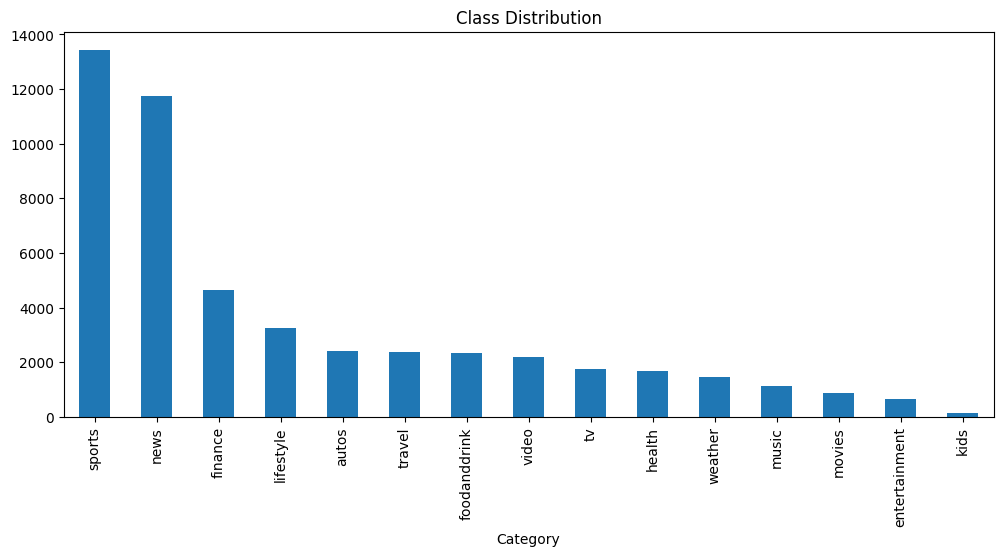

In [4]:
# Class Distribution

import matplotlib.pyplot as plt

df_sample["Category"].value_counts().plot(kind="bar", figsize=(12,5))
plt.title("Class Distribution")
plt.show()

👉 Insight to write:

Dataset is imbalanced

Example: sports >> kids

👉 Impact:

ML models may bias toward majority classes

Transformers handle imbalance better (but still affected)

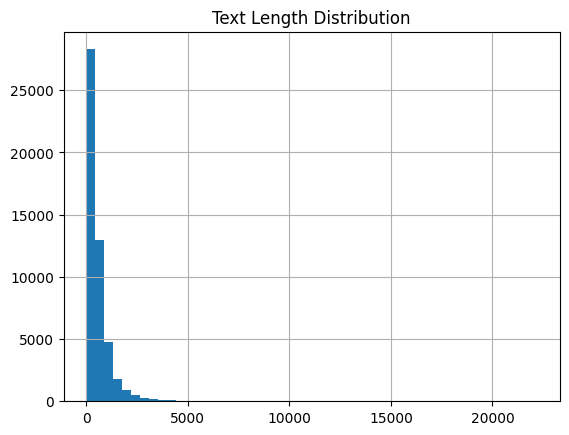

count    49992.000000
mean       558.689550
std        681.099184
min          2.000000
25%        171.000000
50%        379.000000
75%        719.000000
max      22194.000000
Name: text_length, dtype: float64


In [6]:
# Text Length Analysis
df_sample["text_length"] = df_sample["text"].apply(lambda x: len(x.split()))

df_sample["text_length"].hist(bins=50)
plt.title("Text Length Distribution")
plt.show()

print(df_sample["text_length"].describe())

👉 Insight:

Many samples >128 tokens

Your truncation (max_length=128) loses information

👉 This directly explains:

➡️ why accuracy is not higher

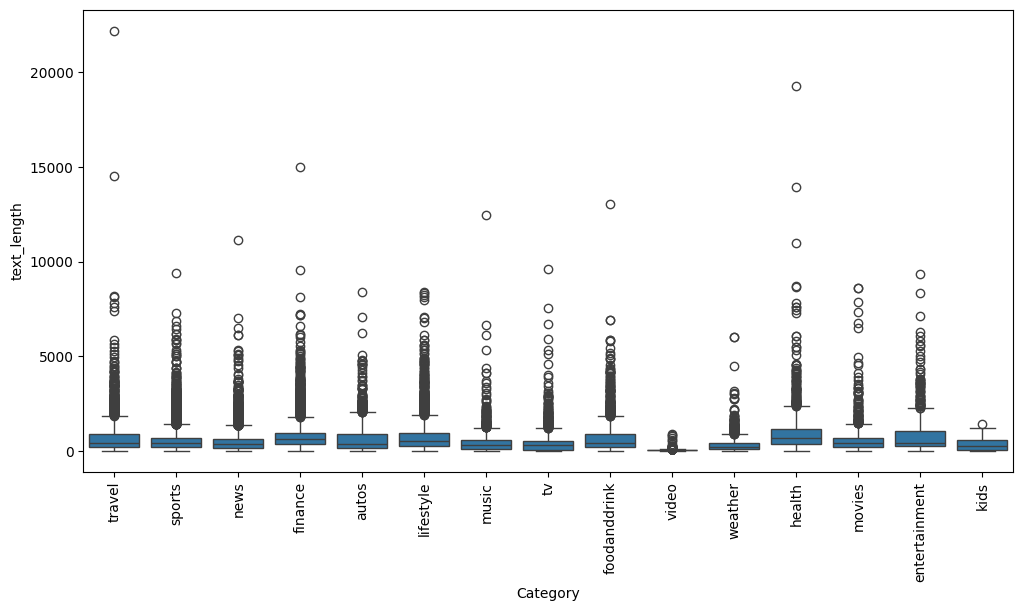

In [7]:
# Category-wise Text Length

import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(x="Category", y="text_length", data=df_sample)
plt.xticks(rotation=90)
plt.show()

👉 Insight:

Some categories (news, sports) have longer texts
Others (kids, weather) are shorter

👉 Impact:

Transformers need dynamic context understanding

In [8]:
# Most Common Words (Global)

from collections import Counter

all_words = " ".join(df_sample["clean_text_cls"]).split()
common_words = Counter(all_words).most_common(20)

print(common_words)

[('the', 1488491), ('to', 710159), ('a', 675537), ('and', 675342), ('of', 583516), ('in', 544556), ('s', 344657), ('for', 288775), ('that', 264588), ('on', 254993), ('is', 244208), ('it', 226904), ('with', 222792), ('at', 174380), ('you', 157202), ('was', 150244), ('as', 147679), ('he', 141736), ('this', 131586), ('i', 127558)]


👉 Insight:

Common stopwords dominate (if not removed)
TF-IDF helps ML models by weighting important words

In [9]:
# Category-wise Top Words

for cat in df_sample["Category"].unique():
    words = " ".join(df_sample[df_sample["Category"]==cat]["clean_text_cls"]).split()
    common = Counter(words).most_common(10)
    print(f"\n{cat}:", common)


travel: [('the', 101386), ('and', 45821), ('to', 42526), ('of', 41209), ('a', 39356), ('in', 32504), ('s', 19836), ('for', 17947), ('is', 16953), ('on', 15463)]

sports: [('the', 396792), ('to', 173971), ('a', 166013), ('and', 147670), ('in', 145265), ('of', 121512), ('s', 88606), ('for', 70913), ('he', 68505), ('on', 67849)]

news: [('the', 314105), ('to', 155464), ('a', 133035), ('and', 131731), ('of', 126180), ('in', 116311), ('s', 67353), ('that', 58632), ('for', 57270), ('on', 53833)]

finance: [('the', 181506), ('to', 99225), ('of', 88175), ('a', 84189), ('and', 80364), ('in', 72069), ('s', 44645), ('for', 42236), ('that', 36548), ('is', 36407)]

autos: [('the', 102297), ('a', 44197), ('and', 42786), ('to', 30940), ('of', 29547), ('in', 24107), ('s', 18726), ('is', 18533), ('it', 17146), ('for', 16390)]

lifestyle: [('the', 109477), ('to', 64261), ('a', 63532), ('and', 63233), ('of', 48924), ('in', 42480), ('you', 28423), ('s', 28168), ('it', 24988), ('for', 24511)]

music: [('t

👉 Insight:

Each category has distinct vocabulary

Example:

sports → game, team

finance → stock, market

👉 This explains:

➡️ Why SVM + TF-IDF performs well

In [11]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


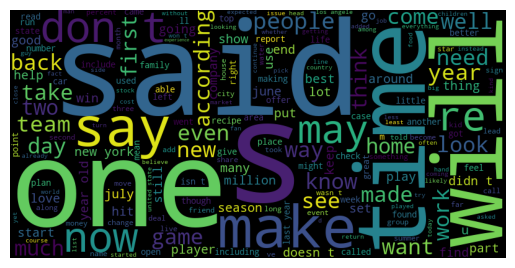

In [13]:
# Word Cloud (Visualization)

from wordcloud import WordCloud

text = " ".join(df_sample["clean_text_cls"])
wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

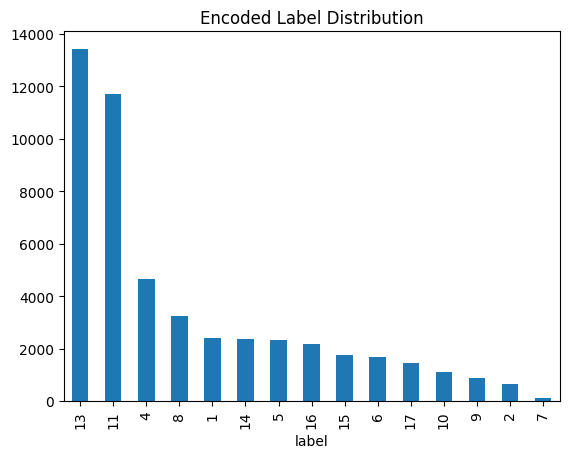

In [14]:
# Label Distribution (Encoded)

df_sample["label"].value_counts().plot(kind="bar")
plt.title("Encoded Label Distribution")
plt.show()

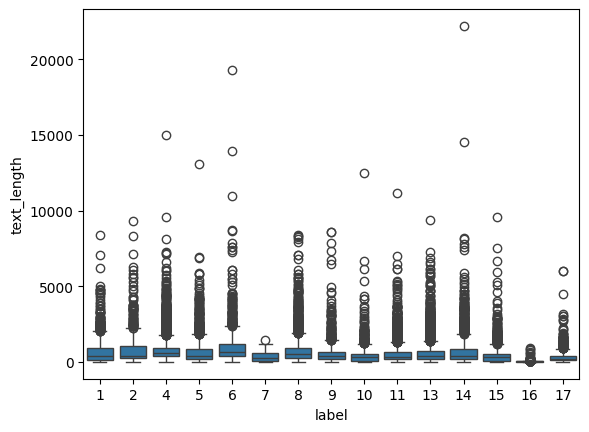

In [15]:
# Correlation: Text Length vs Label

sns.boxplot(x="label", y="text_length", data=df_sample)
plt.show()

🤖 10. Why this EDA matters for your models

🧮 ML Models (TF-IDF, BOW)

Work well because:

Clear word separation between classes

Weakness:

Ignore context

🧠 DL Models (LSTM, CNN)

Performed poorly because:

Not enough training

Sequence length too long

Embeddings not strong

🤖 Transformer Models (BERT, DistilBERT)

Strong because:

Understand context

Limited by:

Truncation (128 tokens)

Low epochs